# **Simulation Tool 2026**

## Installs

In [1]:
%pip install rocketpy==1.12.1

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install CoolProp

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ----------- ---------------------------- 1.6/5.5 MB 12.1 MB/s eta 0:00:01
   ---------------------------- ----------- 3.9/5.5 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 11.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import simulation.simulation as sim
import simulation.deployable_payload as dp
import simulation.utils as utils
import simulation.outputs as outputs

In [85]:
import importlib
importlib.reload(dp)
importlib.reload(sim)
importlib.reload(utils)
importlib.reload(outputs)

<module 'simulation.outputs' from 'g:\\OneDrive - Bildungsdirektion\\Documents\\GitHub\\Lamarr_Flight_Simulation_RocketPy\\simulation\\outputs.py'>

# Simulation

## Configuration

Config rules: 
| Type | Format | Example |Result|
|------|--------|---------|------|
|comment| #... | #comment||
| tuple |a=(x,y) | date=(2025, 10, 12, 17, 00, 00)|(2025, 10, 12, 17, 00, 00)|
|tuple of tuples|a=((v,w)(x,y))|fins_shape_points=((0,0),(0.250,-0.012))|((0,0),(0.250,-0.012))|
|range with increments of x|a=b..c:x|fins_span=110..120:2|[110,112,114,116,118,120]|
|variable with discrete values (float)|a=x,y,z|fins_sweep_length=193,180,200|[193,180,200]| 
|variable with discrete values (string)|a=x,y,z|thrust=thrust_euroc_launch.csv,thrust.csv,thrust_08_25.csv|[thrust_euroc_launch.csv,thrust.csv,thrust_08_25.csv]|

Everything else is a constant
| Type | Format | Example |
|------|--------|---------|
constant|a=x|latitude=39.232465|

Boolean values only possible in constants and variable with discrete values!


In [74]:
# TODO: config generation

In [75]:
project = "ALBATROSS"
DEBUG = True

constants, variables = utils.parse_config(project+"/config.txt")
constants, variables = utils.register("project", project, constants, variables)

if DEBUG:
    utils.printmd("# **VARIABLES**")
    for var in variables:
        print(var)

    print()
    print()
    utils.printmd("# **CONSTANTS**")
    for const in constants:
        print(const)

# **VARIABLES**

flight_inclination
flight_heading




# **CONSTANTS**

environment_envType
environment_latitude
environment_longitude
environment_max_expected_height
environment_date
environment_elevation
engine_type
motor_name
motor_total_mass
motor_propellant_mass
motor_diameter
motor_length
motor_burn_time
thrust
rocket_length
rocket_diameter
rocket_dry_mass
rocket_CG
rocket_moment_of_intertia_Z
rocket_moment_of_intertia_XY
nosecone_length
nosecone_kind
railbuttons_upper
railbuttons_lower
tailcone_diameter
tailcone_length
fins_amount
fins_position
fins_shape_points
main_cd_s
main_trigger
main_lag
drogue_cd_s
drogue_trigger
drogue_lag
flight_rail_length
flight_terminate_on_apogee
payload_mass_total
output_level
project


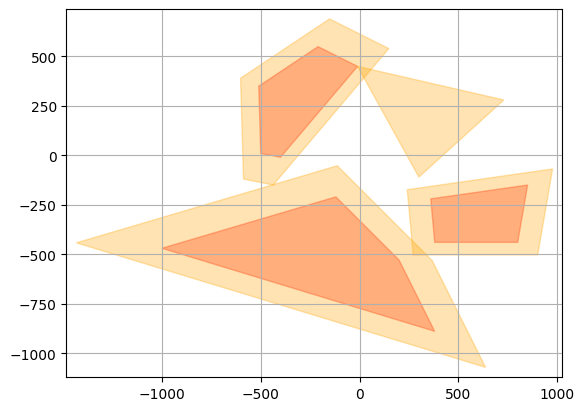

In [76]:

# Define polygons (x = WO, y = NS)
exclusion_zones,buffer_zones = utils.load_zones(project)

dummy_zones = {
    "dummy": [
        (-750,400),
        (250,-200),
        (400,400)
    ]
}
constants, variables = utils.register("exclusion_zones", exclusion_zones, constants, variables)
constants, variables = utils.register("buffer_zones", buffer_zones, constants, variables)
constants, variables = utils.register("dummy_zones", dummy_zones, constants, variables)
constants, variables = utils.register("zones", buffer_zones, constants, variables)


#buffer_zones = {} # comment out to activate exclusion zone "Wald"

buffer_zones.update(utils.scale_zones(exclusion_zones, 1.5))

#buffer_zones = exclusion_zones # comment out to activate buffer zones

utils.plot_safe_flights(project, exclusion_zones, buffer_zones, {}, plot_name="ZONES")

## Environments Initialization




In this Section the environments are initialized.
*   **Forecast**: environment with the weather data from the wyoming-sounding data source at the location and date of EuRoc
*   **Normal**: normalized environment with standard atmospheric values at the time and location of EuRoc
*   **Custom**: custom environment with variable values for temperature and windspeed
*   **Reanalysis**: environment, in which past weather conditions can be used


In [77]:
constants, variables = sim.create_environment(constants, variables)

Creating environment...


## Tanks / Engine



In [78]:
constants, variables = sim.create_engine(constants, variables)

Creating engine...
Creating solid engine...


## Rocket

In [79]:
constants, variables = sim.create_rocket(constants, variables)

Creating rocket...
Creating nosecone...
Creating tailcone...
Creating fins...
Creating parachutes...


## Flight

In [80]:
constants, variables = sim.create_flight(constants, variables)

Creating flights...
108
9%
19%
28%
37%
46%
56%
65%
74%
83%
93%
100%


## Deployable Payloads (for CANSAT)

CanSat Weight: 300 - 350 g \
CanSat Radius: 66 mm \
CanSat Length: 115 mm \
CanSats per launch: 6 \
6 x 300 g = 1800 g

Creating rocket without payload...

Inertia Details

Rocket Mass: 17.770 kg (without motor)
Rocket Dry Mass: 18.502 kg (with unloaded motor)
Rocket Loaded Mass: 19.805 kg
Rocket Structural Mass Ratio: 0.934
Rocket Inertia (with unloaded motor) 11: 18.296 kg*m2
Rocket Inertia (with unloaded motor) 22: 18.296 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.038 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.065 m
Rocket Frontal Area: 0.013273 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.061 m
Rocket Center of Dry Mass - Nozzle Exit: 1.760 m
Rocket Center of Dry Mass - Center of Propellant Mass: 1.476 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.097 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Freeform Lift Coefficient Deriva

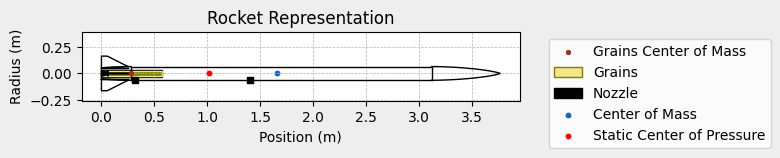


Mass Plots
----------------------------------------


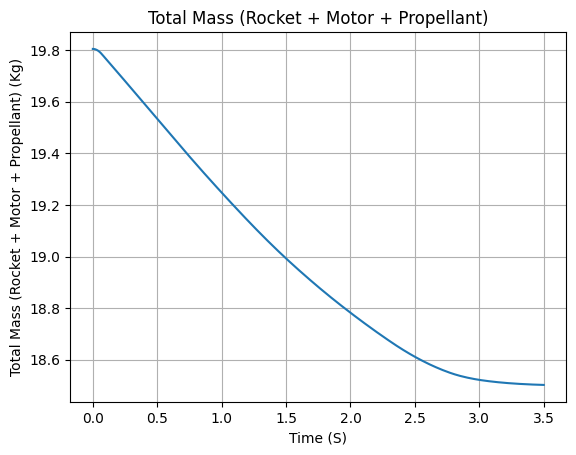

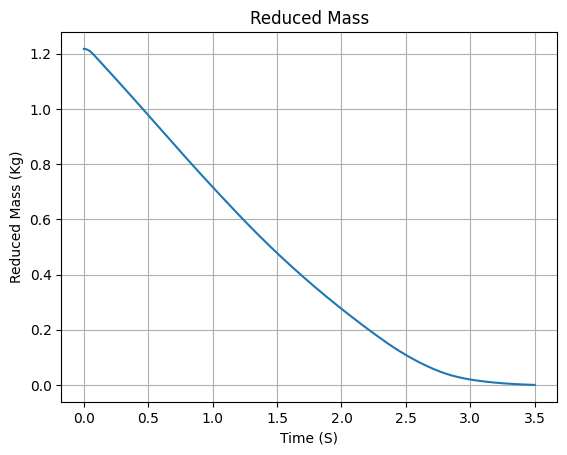


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


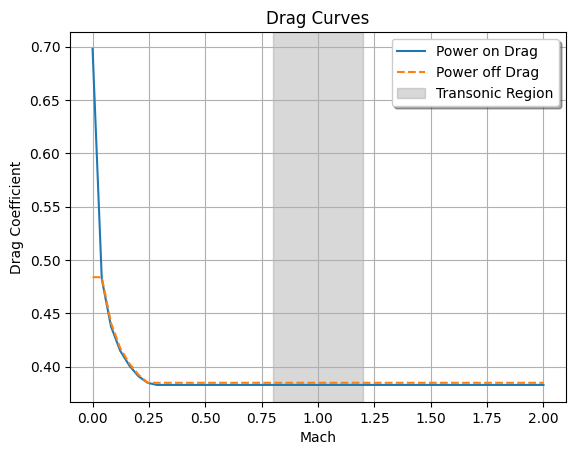


Stability Plots
--------------------


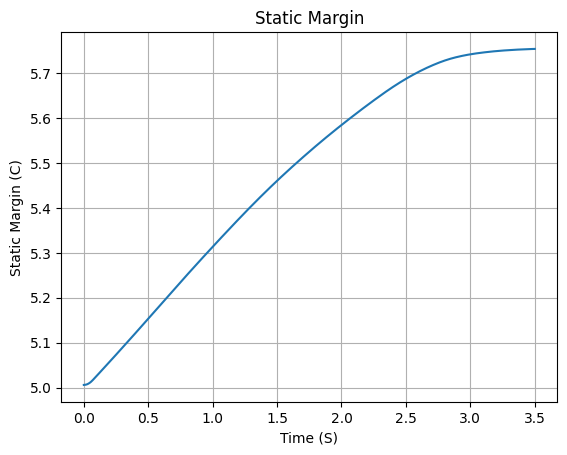

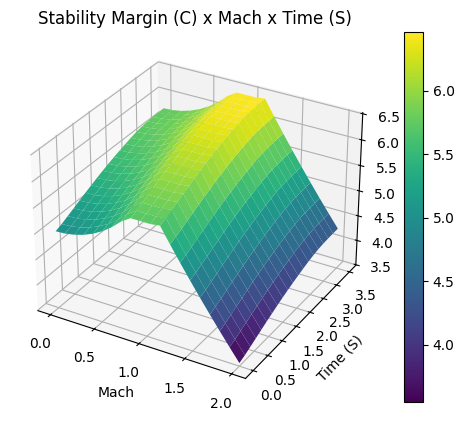


Thrust-to-Weight Plot
----------------------------------------


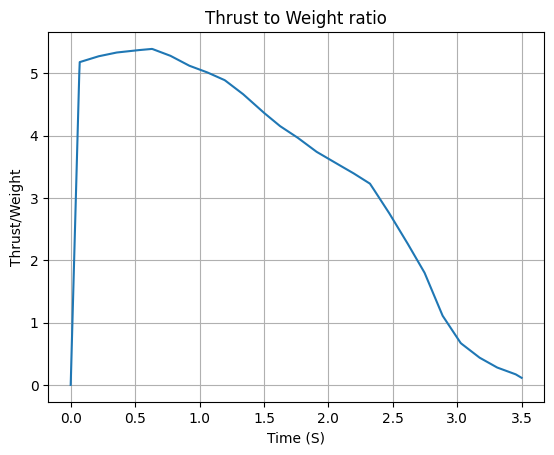


Inertia Details

Rocket Mass: 17.770 kg (without motor)
Rocket Dry Mass: 18.502 kg (with unloaded motor)
Rocket Loaded Mass: 19.805 kg
Rocket Structural Mass Ratio: 0.934
Rocket Inertia (with unloaded motor) 11: 18.296 kg*m2
Rocket Inertia (with unloaded motor) 22: 18.296 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.038 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.065 m
Rocket Frontal Area: 0.013273 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.061 m
Rocket Center of Dry Mass - Nozzle Exit: 1.760 m
Rocket Center of Dry Mass - Center of Propellant Mass: 1.476 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.097 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Freeform Lift Coefficient Derivative: 6.050/rad
Tail Lift Coefficie

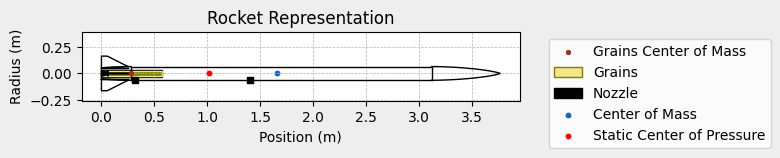


Mass Plots
----------------------------------------


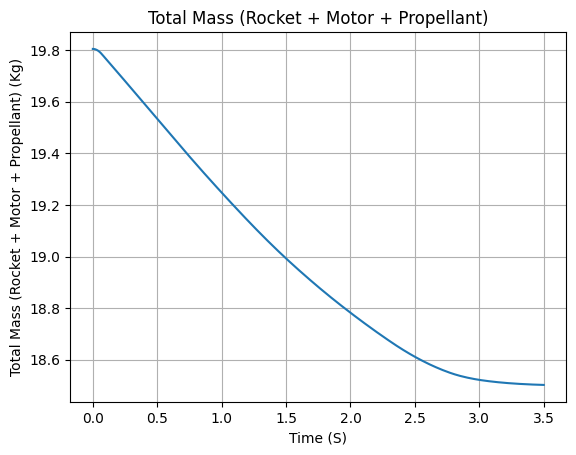

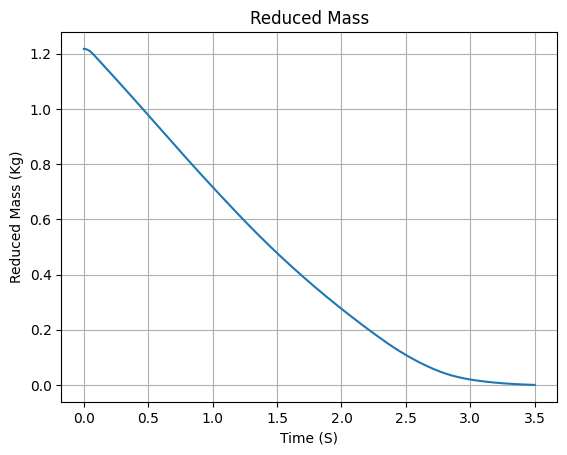


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


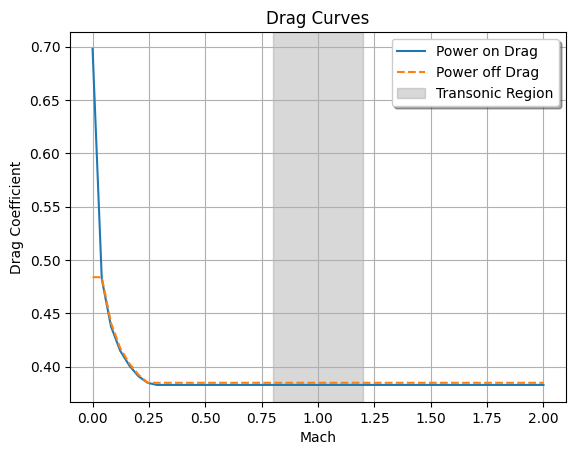


Stability Plots
--------------------


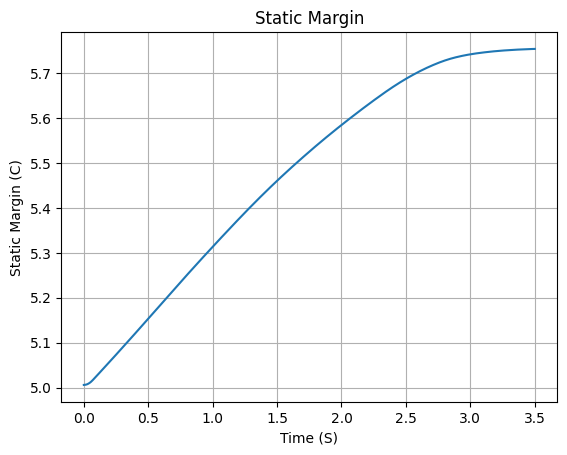

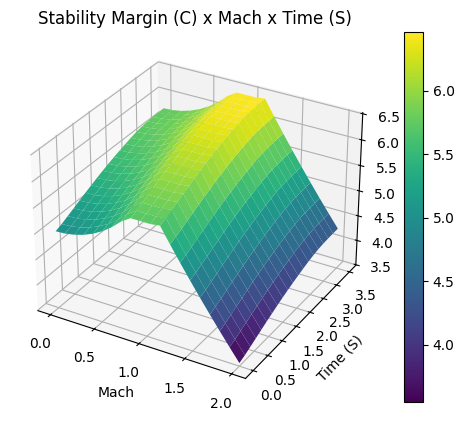


Thrust-to-Weight Plot
----------------------------------------


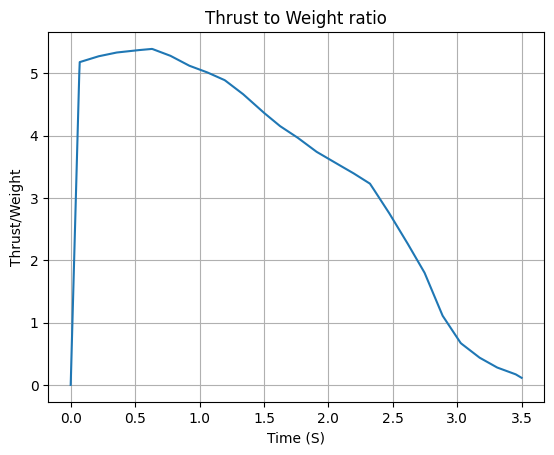

Creating flight without payload...
324
9%
19%
28%
37%
46%
56%
65%
74%
83%
93%
100%


In [81]:
if project == "CANSAT" or project == "ALBATROSS":
    constants, variables = dp.create_rocket_without_payload(constants, variables)
    constants, variables = dp.create_flight_without_payload(constants, variables)
if project == "CANSAT":
    constants, variables = dp.create_payload(constants, variables)
    constants, variables = dp.create_payload_flight(constants, variables)

## Output

In [82]:
if project == "CANSAT":
    utils.plot_safe_flights(project, exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (utils.lookup("flight_without_payload", constants, variables)[0], "green"),
        "payload_nominal": (utils.lookup("flight_payload", constants, variables)[0], "blue")
    }, plot_name = "all_flights")

    outputs.calculate_safe_flights(constants, variables, buffer_zones)

    # ===============================
    # Plot safe flights with zones
    # ===============================
    utils.plot_safe_flights(project, exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (utils.lookup("safe_rocket_nominal", constants, variables)[0], "green"),
        "rocket_no_main": (utils.lookup("safe_rocket_no_main", constants, variables)[0], "orange"),
        "rocket_ballistic": (utils.lookup("safe_rocket_ballistic", constants, variables)[0], "red"),
        "payload_nominal": (utils.lookup("safe_payload_nominal", constants, variables)[0], "blue"),
        }
    )

## **Safe Inclinations per heading**
**Heading 0.0: [86.0, 88.0, 90.0]**
**Heading 10.0: [86.0, 88.0, 90.0]**
**Heading 20.0: [86.0, 88.0, 90.0]**
**Heading 30.0: [86.0, 88.0, 90.0]**
**Heading 40.0: [86.0, 88.0, 90.0]**
**Heading 50.0: [86.0, 88.0, 90.0]**
**Heading 60.0: [86.0, 88.0, 90.0]**
**Heading 70.0: [86.0, 88.0, 90.0]**
**Heading 80.0: [86.0, 88.0, 90.0]**
**Heading 90.0: [86.0, 88.0, 90.0]**
**Heading 100.0: [86.0, 88.0, 90.0]**
**Heading 110.0: [86.0, 88.0, 90.0]**
**Heading 120.0: [86.0, 88.0, 90.0]**
**Heading 130.0: [86.0, 88.0, 90.0]**
**Heading 140.0: [86.0, 88.0, 90.0]**
**Heading 150.0: [86.0, 88.0, 90.0]**
**Heading 160.0: [86.0, 88.0, 90.0]**
**Heading 170.0: [86.0, 88.0, 90.0]**
**Heading 180.0: [86.0, 88.0, 90.0]**
**Heading 240.0: [86.0, 88.0, 90.0]**
**Heading 250.0: [86.0, 88.0, 90.0]**
**Heading 260.0: [86.0, 88.0, 90.0]**
**Heading 270.0: [86.0, 88.0, 90.0]**
**Heading 280.0: [86.0, 88.0, 90.0]**
**Heading 290.0: [86.0, 88.0, 90.0]**
**Heading 300.0: [86.0, 

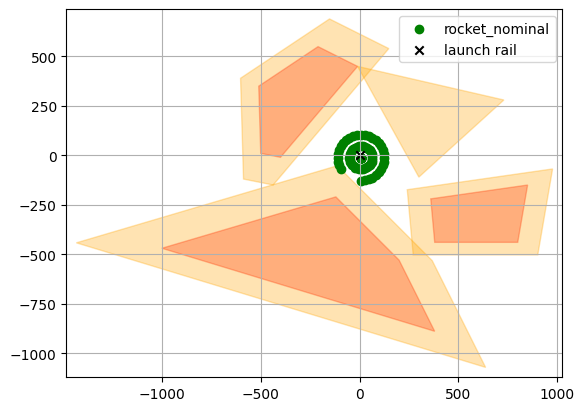

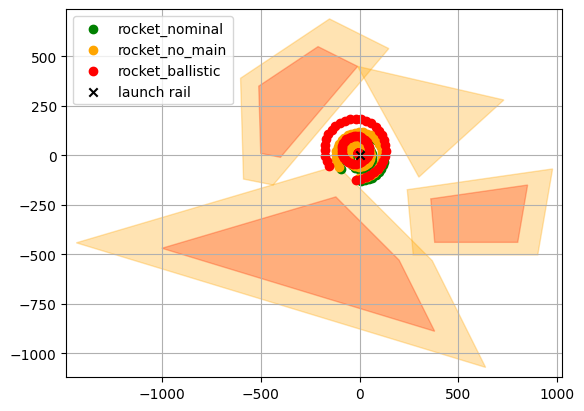

In [86]:
if project == "ALBATROSS":
    utils.plot_safe_flights(project, exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (utils.lookup("flight_without_payload", constants, variables)[0], "green"),
        #"payload_nominal": (utils.lookup("flight_payload", constants, variables)[0], "blue")
    }, plot_name = "all_flights")

    outputs.calculate_safe_flights_no_payload(constants, variables, buffer_zones)

    # ===============================
    # Plot safe flights with zones
    # ===============================
    utils.plot_safe_flights(project, exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (utils.lookup("safe_rocket_nominal", constants, variables)[0], "green"),
        "rocket_no_main": (utils.lookup("safe_rocket_no_main", constants, variables)[0], "orange"),
        "rocket_ballistic": (utils.lookup("safe_rocket_ballistic", constants, variables)[0], "red"),
        #"payload_nominal": (utils.lookup("safe_payload_nominal", constants, variables)[0], "blue"),
        }
    )

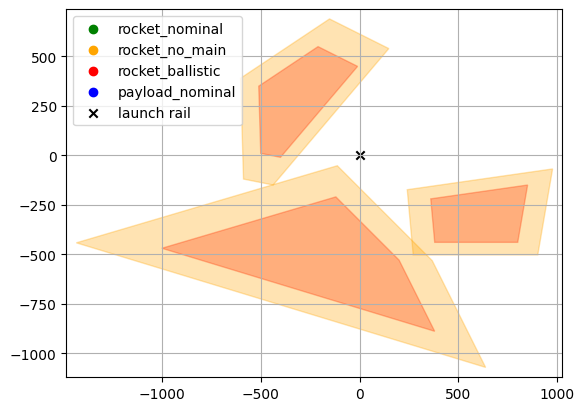

In [ ]:
if project == "CANSAT":
    # Plot all flights for single heading
    heading_to_plot = 330

    utils.plot_safe_flights(project, exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (utils.lookup("safe_rocket_nominal", constants, variables)[0], "green"),
        "rocket_no_main": (utils.lookup("safe_rocket_no_main", constants, variables)[0], "orange"),
        "rocket_ballistic": (utils.lookup("safe_rocket_ballistic", constants, variables)[0], "red"),
        "payload_nominal": (utils.lookup("safe_payload_nominal", constants, variables)[0], "blue"),
    }, heading = heading_to_plot)

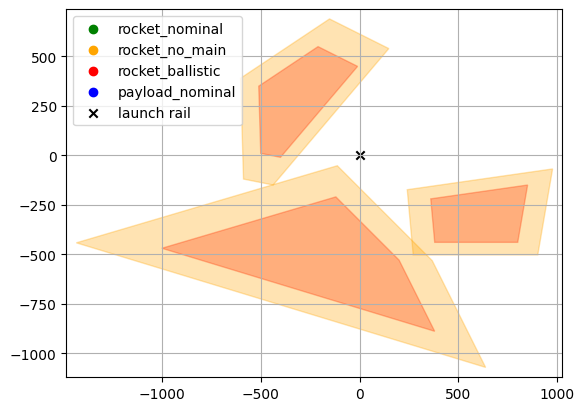

In [ ]:
if project == "CANSAT":
    # Plot all flights for single heading and inclination
    inclination_to_plot = 84

    utils.plot_safe_flights(project, exclusion_zones, buffer_zones, flight_groups={
        "rocket_nominal": (utils.lookup("safe_rocket_nominal", constants, variables)[0], "green"),
        "rocket_no_main": (utils.lookup("safe_rocket_no_main", constants, variables)[0], "orange"),
        "rocket_ballistic": (utils.lookup("safe_rocket_ballistic", constants, variables)[0], "red"),
        "payload_nominal": (utils.lookup("safe_payload_nominal", constants, variables)[0], "blue"),
    }, heading = heading_to_plot, inclination = inclination_to_plot)

In [ ]:
# Print output information
if len(variables) == 0: 
    utils.printmd("""
Level 0 = no output

Level 1 = Flight short recap

Level 2 = All major components short recap

Level 3 = Flight full recap

Level 4 = All major components full recap""")

In [ ]:
if len(variables) == 0: output_level, _ = utils.lookup("output_level", constants, variables)

In [ ]:
# TODO: what if there are more/other envs/motors/rockets/flights?
if len(variables) == 0:
     output_level, _ = utils.lookup("output_level", constants, variables)
     enabled_env_types, _ = utils.lookup("enabled_env_types", constants, variables) # Forecast, Normal, Reanalysis or Custom

     if "Forecast" in enabled_env_types:
          flight, _ = utils.lookup("forecast_flight", constants, variables)
          rocket, _ = utils.lookup("rocket", constants, variables)
          motor, _ = utils.lookup("motor", constants, variables) if utils.lookup("engine_type", constants, variables)[0] == "solid" else utils.lookup("engine", constants, variables)
          environment, _ = utils.lookup("envForecast", constants, variables)
          
     if output_level >= 1 and output_level <=2:
          utils.printmd(f"""
# **Rail Departure**
Velocity: {flight.out_of_rail_velocity: .2f} m/s

Stability Margin: {flight.out_of_rail_stability_margin: .2f} c

# **Apogee**
Time: {flight.apogee_time: .2f} s

Altitude: {(flight.apogee - flight.env.elevation): .2f} m AGL

Freestream Speed: {flight.apogee_freestream_speed: .2f} m/s

# **Impact**
Velocity: {flight.impact_velocity: .2f} m/s

# **Maximum Values**
Max Speed: {flight.max_speed: .2f} m/s at {flight.max_speed_time: .2f} s

Max Mach Number: {flight.max_mach_number: .2f} Mach at {flight.max_mach_number_time: .2f} s

Max Acceleration: {flight.max_acceleration: .2f} m/s² at {flight.max_acceleration_time: .2f} s

Max Gs: {(flight.max_acceleration/9.81): .2f} g at {flight.max_acceleration_time: .2f} s

Max Stability Margin: {flight.max_stability_margin: .2f} c at {flight.max_stability_margin_time: .2f} s

# **PLOTS**
""")
          flight.plots.trajectory_3d()
          flight.plots.aerodynamic_forces()
          flight.plots.stability_and_control_data()
     elif output_level == 2:
          utils.printmd(f"""
# **Rocket**
Rocket Dry Mass: {rocket.mass: .3f} kg (without motor)

Rocket Loaded Mass: {rocket.total_mass(0): .3f} kg

# **PLOTS**
""") 
          rocket.draw()
          rocket.plots.thrust_to_weight()
          rocket.plots.stability_margin()
          utils.printmd(f"""
# **Motor**
Total Burning Time: {motor.burn_time} s

Total Propellant Mass: {motor.propellant_mass(0): .2f} kg

Average Thrust: {motor.average_thrust: .2f} N

Maximum Thrust: {motor.max_thrust: .2f} N at {motor.max_thrust_time: .2f} s after ignition.

Total Impulse: {motor.total_impulse: .2f} Ns
""") 
          motor.draw()
          motor.plots.thrust()
          utils.printmd(f"""
# **Environment**

Launch Site Surface Elevation: {environment.elevation: .2f} m

Surface Wind Speed: {environment.wind_speed(0): .2f} m/s

Surface Wind Direction: {environment.wind_direction(0): .2f}°

Surface Wind Heading: {environment.wind_heading(0): .2f}°

# **PLOTS**
""")
          environment.plots.atmospheric_model()
     elif output_level == 3:
          flight.all_info()
     elif output_level == 4:
          environment.all_info()
          motor.all_info()
          rocket.all_info()
          flight.all_info()

# Comparsion

In [ ]:

# TODO (continuous): add in/output, so user does not have to open the code
if project == "CANSAT":
    legend = False
    all_flights = utils.lookup("all_flights", constants, variables)[0]

    #for flight in all_flights:
    #    print(flight.name)
        # print(flight._meta)
    comparison_normal = sim.CompareFlights(all_flights)
    comparison_normal.trajectories_3d(legend=legend, filename = project + "/plots/3d.png")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xy.png", plane = "xy")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xz.png", plane = "xz")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_yz.png", plane = "yz")

Plot saved to file: CANSAT/plots/2d_xy_all.png
Plot saved to file: CANSAT/plots/2d_yz_all.png


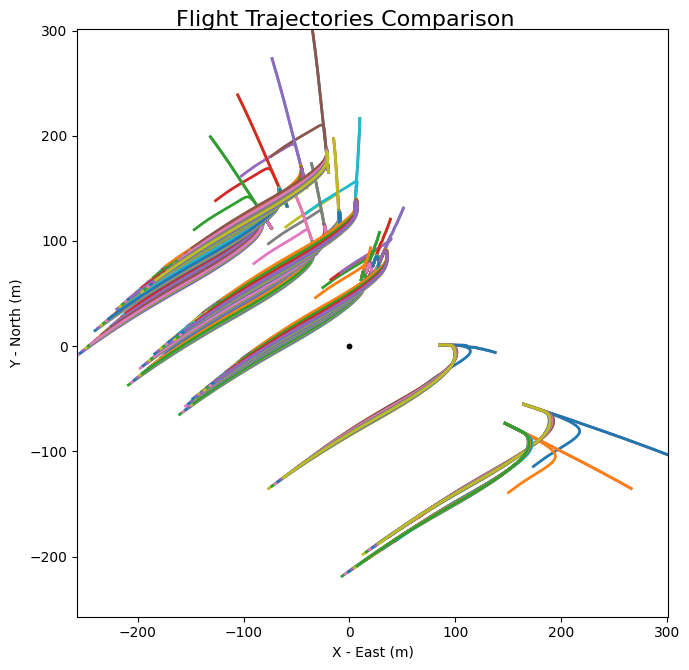

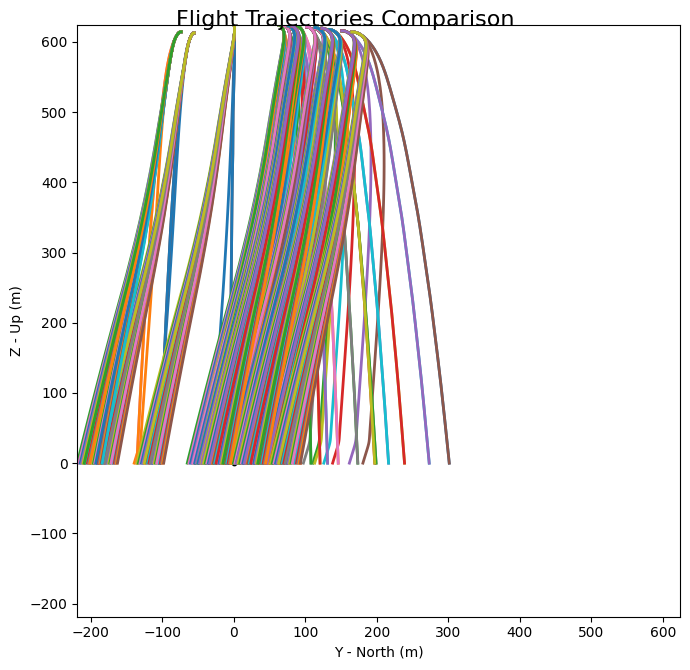

In [36]:
# Info: won't work if there is no safe flight
if project == "CANSAT":
    legend = False
    all_safe_flights = utils.lookup("safe_rocket_nominal", constants, variables)[0] + utils.lookup("safe_rocket_no_main", constants, variables)[0] + utils.lookup("safe_rocket_ballistic", constants, variables)[0] + utils.lookup("safe_payload_nominal", constants, variables)[0]

    #for flight in all_flights:
        # print(flight.name)
        # print(flight._meta)
    comparison_normal = sim.CompareFlights(all_safe_flights)
    comparison_normal.trajectories_3d(legend=legend, filename = project + "/plots/3d_all.png")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xy_all.png", plane = "xy")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_xz_all.png", plane = "xz")
    comparison_normal.trajectories_2d(legend=legend, filename = project + "/plots/2d_yz_all.png", plane = "yz")

## Export

In [ ]:
# Save notebook for nbconvert to use newest data
#!pip install keyboard
import keyboard
keyboard.press_and_release('control+s')

In [ ]:
!jupyter nbconvert simulation.ipynb --to html --no-input --no-prompt --output {project}/report.html --log-level ERROR

In [4]:
!pip install segno

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wattikan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import segno

# -------------------------
# Contact information (vCard)
# -------------------------
first_name = "Diego"
last_name = "Gruenberger"
phone = "+393920481711"
email = "diego.gruenberger@spaceteam.at"
company = "TU Wien Space Team"
title = "Liquid Rocketry | HR"
website = "https://spaceteam.at"

vcard = f"""BEGIN:VCARD
VERSION:3.0
N:{last_name};{first_name}
FN:{first_name} {last_name}
ORG:{company}
TITLE:{title}
TEL;TYPE=CELL:{phone}
EMAIL:{email}
URL:{website}
END:VCARD
"""

# -------------------------
# Generate QR
# -------------------------
qr = segno.make(vcard, error='h')

matrix = [list(row) for row in qr.matrix]

size = len(matrix)

# Size of transparent center (modules)
center_size = size // 4

start = (size - center_size) // 2
end = start + center_size

# Remove modules in center
for y in range(start, end):
    for x in range(start, end):
        matrix[y][x] = 0

# -------------------------
# Write SVG manually
# -------------------------
scale = 10
with open("contact_qr.svg", "w") as f:
    f.write(f'<svg xmlns="http://www.w3.org/2000/svg" '
            f'viewBox="0 0 {size} {size}" '
            f'width="{size*scale}" height="{size*scale}">\n')

    for y, row in enumerate(matrix):
        for x, val in enumerate(row):
            if val:
                f.write(f'<rect x="{x}" y="{y}" width="1" height="1" fill="white"/>\n')

    f.write("</svg>")


In [25]:
!pip install svgwrite

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wattikan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import segno

# Deine Variablen (Beispiel)
first_name = "Diego"
last_name = "Grünberger"
phone = "+393920481711"
email = "diego.gruenberger@spaceteam.at"
company = "TU Wien Space Team"
title = "Liquid Rocketry | HR"
website = "https://spaceteam.at"

# 1. UTF-8 explizit im vCard-String angeben (CHARSET=UTF-8)
vcard = f"""BEGIN:VCARD
VERSION:3.0
N;CHARSET=UTF-8:{last_name};{first_name}
FN;CHARSET=UTF-8:{first_name} {last_name}
ORG;CHARSET=UTF-8:{company}
TITLE;CHARSET=UTF-8:{title}
TEL;TYPE=CELL:{phone}
EMAIL:{email}
URL:{website}
END:VCARD
"""

# 2. Segno übernimmt das Encoding automatisch richtig
qr = segno.make(vcard, error='h')

matrix = [list(row) for row in qr.matrix]
size = len(matrix)

center_size = size // 4
start = (size - center_size) // 2
end = start + center_size

for y in range(start, end):
    for x in range(start, end):
        matrix[y][x] = False

scale = 10
with open("contact_qr.svg", "w", encoding="utf-8") as f:
    f.write(f'<svg xmlns="http://www.w3.org/2000/svg" '
            f'viewBox="0 0 {size} {size}" '
            f'width="{size*scale}" height="{size*scale}" shape-rendering="crispEdges">\n')
    # Hintergrund weiß
    f.write(f'<rect width="{size}" height="{size}" fill="white"/>\n')
    for y, row in enumerate(matrix):
        for x, val in enumerate(row):
            if val:
                # Module schwarz zeichnen, damit sie sichtbar sind
                f.write(f'<rect x="{x}" y="{y}" width="1" height="1" fill="black"/>\n')
    f.write("</svg>")

print("QR code mit 'ü' Unterstützung gespeichert.")


QR code mit 'ü' Unterstützung gespeichert.
